# Header

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import cmdstanpy
import arviz as az

In [2]:
n_chains = 4
iter_warmup = 1000
iter_sampling = 1000

In [3]:
import boto3
from configparser import ConfigParser
import awswrangler as wr

config = ConfigParser()
config.read(r'C:\Users\RyanKarel\.aws\credentials')

boto3_session = boto3.session.Session(
    aws_access_key_id=config['218527194748_ActuaryAccessProd']['aws_access_key_id'],
    aws_secret_access_key=config['218527194748_ActuaryAccessProd']['aws_secret_access_key'],
    aws_session_token=config['218527194748_ActuaryAccessProd']['aws_session_token'],
    region_name='us-east-1',
)

def query_athena(
    sql: str,
    boto3_session,
    database: str = "rn_actuary_db",
    workgroup: str = "Actuary",
    index_col = None,
    check_index_uniqueness: bool = True,
    force_index_uniqueness: bool = False,
) -> pd.DataFrame:
    output = wr.athena.read_sql_query(
        sql=sql,
        database=database,
        boto3_session=boto3_session,
        workgroup=workgroup,
        ctas_approach=False,
    )
    if index_col is not None:
        if force_index_uniqueness:
            output.drop_duplicates(subset=index_col, inplace=True)
        output.set_index(index_col, inplace=True)
        if check_index_uniqueness:
            assert output.index.is_unique
    return output

# ITD Simplified Data Prep

In [4]:
itd_sql = """
with claim_stats as (
    select
        num_claim,
        num_policy,
        c.cd_cause_of_loss,
        c.cd_severity,
        p.cd_product,
        c.cd_occurrence_state,
        lcg.cd_group_name as cd_largest_class_group,
        coalesce(p.amt_occurrence_limit, p.amt_claim_limit) as amt_claim_limit,
        c.dt_claim_report,
        timestamp_settlement as dt_settlement,
        if(cd_claim_status = 'Closed', dt_claim_closed) as dt_claim_closed,
        greatest(
            date_diff(
                'day',
                dt_claim_report,
                coalesce(timestamp_settlement, if(cd_claim_status = 'Closed', dt_claim_closed))
            ) / 365.0,
            0.001
        ) as settlement_lag,
        greatest(
            date_diff(
                'day',
                dt_claim_report, -- making everything relative to report date for consistency
                if(cd_claim_status = 'Closed', dt_claim_closed)
            ) / 365.0,
            0.001
        ) as closure_lag,
        greatest(
            date_diff(
                'day',
                dt_claim_report,
                current_timestamp
            ) / 365.0,
            0.001
        ) as age
    from tbl_claim c
    inner join tbl_policy p using (num_policy)
    left join (select num_claim, timestamp_settlement from tbl_settlement) s using (num_claim)
    left join vw_largest_class_group lcg using (num_policy)
    where
        coalesce(p.amt_total_attachment, 0) = 0 -- primary layer only
        and p.cd_product not in ('CP', 'IM') -- non property
        and dt_claim_report < current_timestamp - interval '3' month
),

transactions as (
    select
        num_claim,
        sum(coalesce(amt_paid, 0)) filter (where ind_loss and not ind_recovery) as paid_loss,
        sum(coalesce(amt_incurred, 0)) filter (where ind_loss and not ind_recovery) as incurred_loss,
        sum(coalesce(amt_paid, 0)) filter (where ind_dcc and not ind_recovery) as paid_dcc,
        sum(coalesce(amt_incurred, 0)) filter (where ind_dcc and not ind_recovery) as incurred_dcc,
        sum(coalesce(amt_incurred, 0)) filter (where ind_recovery) as recoveries
    from (
        select
            *,
            cd_financial_type = 'Loss' as ind_loss,
            cd_financial_type = 'DCC' as ind_dcc,
            cd_claim_transaction_type like 'Recov%' as ind_recovery
        from tbl_claim_transaction
    ) t
    inner join claim_stats c using (num_claim)
    where cd_financial_type != 'AO'
    group by 1
)

select *
from claim_stats c
inner join transactions t using (num_claim)
"""

In [5]:
itd_data = query_athena(
    sql=itd_sql,
    boto3_session=boto3_session
)
itd_data.set_index('num_claim', inplace=True)
itd_data = itd_data.loc[itd_data['incurred_loss'] > 100]

def fct_lump(s: pd.Series, min_frequency: float = None, top_n: int = None, infrequent_level: str = 'Other'):
    if top_n is not None:
        assert min_frequency is None
        assert isinstance(top_n, int) and top_n > 0

        frequencies = s.value_counts(normalize=True, dropna=True)
        keep_levels = frequencies.nlargest(top_n).index

        return s.where(s.isna() | s.isin(keep_levels), infrequent_level).fillna(infrequent_level)

    assert min_frequency is not None
    assert 0 <= min_frequency <= 1
    frequencies = s.value_counts(normalize=True, dropna=True)
    rare_levels = frequencies[frequencies < min_frequency].index

    return (
        s.where(~s.isin(rare_levels) | s.isna(), infrequent_level)
    ).fillna(infrequent_level)

scale = 1000

forced_minimum_dcc = 0 # pre-scaling

itd_data['cd_cause_of_loss'] = fct_lump(itd_data['cd_cause_of_loss'], top_n=30)
itd_data['cd_largest_class_group'] = fct_lump(itd_data['cd_largest_class_group'], top_n=30)
itd_data['cd_occurrence_state'] = fct_lump(itd_data['cd_occurrence_state'], top_n=10)
itd_data['incurred_loss'] = itd_data['incurred_loss'] / scale
itd_data['incurred_dcc'] = np.maximum(itd_data['incurred_dcc'].fillna(0), forced_minimum_dcc) / scale
itd_data

,num_policy,cd_cause_of_loss,cd_severity,cd_product,cd_occurrence_state,cd_largest_class_group,amt_claim_limit,dt_claim_report,dt_settlement,dt_claim_closed,settlement_lag,closure_lag,age,paid_loss,incurred_loss,paid_dcc,incurred_dcc,recoveries
num_claim,,,,,,,,,,,,,,,,,,
RN-9-0000104,RN-7-0324273,Premises/Slip/Trip/ fall,1,GC,FL,Hotels and Motels,1000000.0000,2022-07-13,None,2024-05-15,1.841096,1.841096,4.128767,419.11,0.41911,30599.83,30.59983,NaN
RN-9-0000134,RN-7-0324210,Premises/Slip/Trip/ fall,2,GC,FL,Condominiums,1000000.0000,2022-11-14,2024-06-03,2024-08-20,1.553425,1.767123,3.789041,40000.00,40.00000,81604.27,81.60427,-5000.0
RN-9-0000143,RN-7-0324265,Discrimination-Employment-Racial,3,PE,Other,School Boards,1000000.0000,2022-12-06,2023-04-26,2023-04-26,0.386301,0.386301,3.728767,35000.00,35.00000,0.00,0.00000,NaN
RN-9-0000154,RN-7-0324946,Premises/Slip/Trip/ fall,2,GC,FL,Condominiums,1000000.0000,2023-01-10,2024-09-24,2024-09-24,1.706849,1.706849,3.632877,5015.63,5.01563,8812.82,8.81282,NaN
RN-9-0000167,RN-7-0324559,Other,2,PL,FL,Insurance Agents,1000000.0000,2023-01-25,2024-12-30,None,1.931507,NaN,3.591781,60000.00,60.00000,116333.80,116.33380,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
RN-9-0003485,RN-7-0502561,Line Strike,3,CN,TX,Digging,1000000.0000,2026-04-07,2026-06-15,2026-06-15,0.189041,0.189041,0.391781,10000.00,10.00000,NaN,0.00000,NaN
RN-9-0003647,RN-7-0329103,Other,3,PE,Other,School Boards,1000000.0000,2026-05-04,None,None,NaN,NaN,0.317808,0.00,5.00000,NaN,0.00000,NaN
RN-9-0003664,RN-7-0327214-02,Discrimination-Employment-ADA,3,PE,FL,Public Officials,2000000.0000,2026-05-07,None,None,NaN,NaN,0.309589,20000.00,24.00000,NaN,0.00000,NaN


# EDA

## Absorbing states

Using queries like the following, I've determined that ind_litigation only rarely gets switched back (1.1% of the time) to 0 after being activated. This happens 4% of the time with ind_coverage_disclaimer, but a whole 16% of the time with ind_under_detailed_ror. So the latter may need to be modeled as a non-absorbing state.

```sql
with tmp as (
    select
        num_claim,
        timestamp_modified,
        ind_litigation,
        ind_coverage_disclaimer,
        ind_under_detailed_ror,
        max(ind_litigation) over (partition by num_claim order by timestamp_modified ASC) as ind_litigation_max,
        max(ind_coverage_disclaimer) over (partition by num_claim order by timestamp_modified ASC) as ind_coverage_disclaimer_max,
        max(ind_under_detailed_ror) over (partition by num_claim order by timestamp_modified ASC) as ind_under_detailed_ror_max
    from tbl_claim_snapshot
    where dt_claim_report > date('2023-09-01')
    order by 1, 2
),

by_claims as (
    select
        num_claim,
        sign(sum(cast(ind_litigation = 0 and ind_litigation_max = 1 as int))) as deselection
    from tmp
    group by 1
    having max(ind_litigation) = 1
)

select avg(deselection) from by_claims
```

## Severity code changes

Similarly, the claims seem to rarely change severity codes after a couple months since the claim's report. About 7% of the time they'll get more severe, and 4% of the time they get less severe.

```sql
with tmp as (
    select
        num_claim,
        timestamp_modified as t,
        min(timestamp_modified) over (partition by num_claim) as t0,
        max(timestamp_modified) over (partition by num_claim) as tn,
        cast(regexp_extract(cd_severity, '\d') as int) as cd_severity
    from tbl_claim_snapshot
    where dt_claim_report between date('2023-09-01') and date('2025-09-01')
    order by 1, 2
),

normalized_t as (
    select
        num_claim,
        date_diff('day', t0, t)  * 1.0 / date_diff('day', t0, tn) as t,
        cd_severity
    from tmp
    where date_diff('day', t0, t) > 90
),

cumulative_stats as (
    select
        *,
        max(cd_severity) over (partition by num_claim order by t) as max_severity,
        min(cd_severity) over (partition by num_claim order by t) as min_severity
    from normalized_t
    where t > 0.0
),

by_claims as (
    select
        num_claim,
        sign(sum(cast(cd_severity < max_severity as int))) as got_more_severe,
        sign(sum(cast(cd_severity > min_severity as int))) as got_less_severe
    from cumulative_stats
    group by 1
)

select
    avg(got_more_severe) as got_more_severe,
    avg(got_less_severe) as got_less_severe
from by_claims
```

## Development Patterns

### Loss Paid and Incurred

Start with an easy one. Should see that there is typically just a big indemnity payment at the end of the claim's lifecycle.

In [ ]:
eda_sql = """
with increm as (
    select
        num_claim,
        (
            date_diff('day', dt_claim_report, timestamp_claim_transaction)
            * 1.0
            / date_diff('day', dt_claim_report, timestamp_settlement)
        ) as t,
        cd_claim_transaction_type,
        amt_paid,
        amt_incurred
    from tbl_claim_transaction tl
    left join tbl_claim c using (num_claim)
    left join tbl_policy p using (num_policy)
    left join (select num_claim, timestamp_settlement from tbl_settlement) s using (num_claim)
    where
        cd_financial_type = 'Loss'
        and cd_claim_transaction_type not like 'Recovery%'
        and cd_claim_status = 'Closed'
        and coalesce(p.amt_total_attachment, 0) = 0
        and p.cd_product not in ('CP', 'IM')
    order by 1, 2
),

bucket_time as (
    select
        num_claim,
        case when t = 1 then 10 else width_bucket(t, 0, 1, 10) end as t_bucket,
        sum(amt_paid) as amt_paid,
        sum(amt_incurred) as amt_incurred
    from increm
    group by 1, 2
),

all_options_by_claim as (
    select
        c.num_claim,
        t.t_bucket,
        coalesce(b.amt_paid, 0) as amt_paid,
        coalesce(b.amt_incurred, 0) as amt_incurred
    from (select distinct num_claim from bucket_time) c
    cross join (select distinct t_bucket from bucket_time) t
    left join bucket_time b on c.num_claim = b.num_claim and t.t_bucket = b.t_bucket
    order by 1, 2
),

claim_sums as (
    select
        *,
        sum(amt_paid) over (partition by num_claim) as total_amt_paid,
        sum(amt_incurred) over (partition by num_claim) as total_amt_incurred
    from all_options_by_claim
)

select
    t_bucket,
    round(sum(amt_paid) / sum(total_amt_paid), 3) as pct_paid,
    round(sum(amt_incurred) / sum(total_amt_incurred), 3) as pct_incurred
from claim_sums
group by 1
order by 1
"""
devt = query_athena(
    eda_sql,
    boto3_session=boto3_session
).set_index('t_bucket').round(2)
devt.plot(kind='bar', title='Indemnity Distribution')

### DCC Paid and Incurred

Roughly uniform payments on the back half.

In [ ]:
eda_sql = """
with increm as (
    select
        num_claim,
        (
            date_diff('day', dt_claim_report, timestamp_claim_transaction)
            * 1.0
            / date_diff('day', dt_claim_report, timestamp_settlement)
        ) as t,
        cd_claim_transaction_type,
        amt_paid,
        amt_incurred
    from tbl_claim_transaction tl
    left join tbl_claim c using (num_claim)
    left join tbl_policy p using (num_policy)
    left join (select num_claim, timestamp_settlement from tbl_settlement) s using (num_claim)
    where
        cd_financial_type = 'DCC'
        and cd_claim_transaction_type not like 'Recovery%'
        and cd_claim_status = 'Closed'
        and coalesce(p.amt_total_attachment, 0) = 0
        and p.cd_product not in ('CP', 'IM')
    order by 1, 2
),

bucket_time as (
    select
        num_claim,
        case
            when t > 2 then 20
            when t > 1.5 then 15
            when t > 1.4 then 14
            when t > 1.3 then 13
            when t > 1.2 then 12
            when t > 1 then 11
            when t = 1 then 10
            else width_bucket(t, 0, 1, 10) end as t_bucket,
        sum(amt_paid) as amt_paid,
        sum(amt_incurred) as amt_incurred
    from increm
    group by 1, 2
),

all_options_by_claim as (
    select
        c.num_claim,
        t.t_bucket,
        coalesce(b.amt_paid, 0) as amt_paid,
        coalesce(b.amt_incurred, 0) as amt_incurred
    from (select distinct num_claim from bucket_time) c
    cross join (select distinct t_bucket from bucket_time) t
    left join bucket_time b on c.num_claim = b.num_claim and t.t_bucket = b.t_bucket
    order by 1, 2
),

claim_sums as (
    select
        *,
        sum(amt_paid) over (partition by num_claim) as total_amt_paid,
        sum(amt_incurred) over (partition by num_claim) as total_amt_incurred
    from all_options_by_claim
)

select
    t_bucket,
    round(sum(amt_paid) / sum(total_amt_paid), 3) as pct_paid,
    round(sum(amt_incurred) / sum(total_amt_incurred), 3) as pct_incurred
from claim_sums
group by 1
order by 1
"""
devt = query_athena(
    eda_sql,
    boto3_session=boto3_session
).set_index('t_bucket').round(2)
devt.plot(kind='bar', title='DCC Distribution')

### ALAE AO Paid and Incurred

In [ ]:
eda_sql = """
with increm as (
    select
        num_claim,
        (
            date_diff('day', dt_claim_report, timestamp_claim_transaction)
            * 1.0
            / date_diff('day', dt_claim_report, max(timestamp_claim_transaction) over (partition by num_claim))
        ) as t,
        cd_claim_transaction_type,
        amt_paid,
        amt_incurred
    from tbl_claim_transaction tl
    left join tbl_claim c using (num_claim)
    left join tbl_policy p using (num_policy)
    where
        cd_financial_type = 'AO'
        and cd_claim_transaction_type not like 'Recovery%'
        and cd_claim_status = 'Closed'
        and coalesce(p.amt_total_attachment, 0) = 0
        and p.cd_product not in ('CP', 'IM')
    order by 1, 2
),

bucket_time as (
    select
        num_claim,
        case when t = 1 then 10 else width_bucket(t, 0, 1, 10) end as t_bucket,
        sum(amt_paid) as amt_paid,
        sum(amt_incurred) as amt_incurred
    from increm
    group by 1, 2
),

all_options_by_claim as (
    select
        c.num_claim,
        t.t_bucket,
        coalesce(b.amt_paid, 0) as amt_paid,
        coalesce(b.amt_incurred, 0) as amt_incurred
    from (select distinct num_claim from bucket_time) c
    cross join (select distinct t_bucket from bucket_time) t
    left join bucket_time b on c.num_claim = b.num_claim and t.t_bucket = b.t_bucket
    order by 1, 2
),

claim_sums as (
    select
        *,
        sum(amt_paid) over (partition by num_claim) as total_amt_paid,
        sum(amt_incurred) over (partition by num_claim) as total_amt_incurred
    from all_options_by_claim
)

select
    t_bucket,
    round(sum(amt_paid) / sum(total_amt_paid), 3) as pct_paid,
    round(sum(amt_incurred) / sum(total_amt_incurred), 3) as pct_incurred
from claim_sums
group by 1
order by 1
"""
devt = query_athena(
    eda_sql,
    boto3_session=boto3_session
).set_index('t_bucket').round(2)
devt.plot(kind='bar', title='ALAE AO Distribution')

## Gap between settlement & closure

### Timing

In [ ]:
eda_sql = """
with tmp as (
    select
        num_claim,
        dt_claim_closed,
        max_loss_transaction_timestamp,
        max_loss_payment_timestamp,
        max_alae_transaction_timestamp,
        max_all_transaction_timestamp
    from tbl_claim c
    inner join (
        select
            num_claim,
            max(timestamp_claim_transaction) filter (where cd_financial_type = 'Loss' and cd_claim_transaction_type not like 'Recover%') as max_loss_transaction_timestamp,
            max(timestamp_claim_transaction) filter (where cd_financial_type = 'Loss' and cd_claim_transaction_type like 'Pay%') as max_loss_payment_timestamp,
            max(timestamp_claim_transaction) filter (where cd_financial_type != 'Loss' and cd_claim_transaction_type not like 'Recover%') as max_alae_transaction_timestamp,
            max(timestamp_claim_transaction) filter (where cd_claim_transaction_type not like 'Recover%') as max_all_transaction_timestamp
        from tbl_claim_transaction
        group by 1
    ) as tl using (num_claim)
    where
        cd_claim_status = 'Closed'
        and amt_total_paid >= 10000
)

select
    *,
    date_diff('day', max_loss_transaction_timestamp, dt_claim_closed) as closure_vs_loss_transaction,
    date_diff('day', max_loss_payment_timestamp, dt_claim_closed) as closure_vs_loss_payment,
    date_diff('day', max_alae_transaction_timestamp, dt_claim_closed) as closure_vs_alae_transaction,
    date_diff('day', max_all_transaction_timestamp, dt_claim_closed) as closure_vs_all_transaction
from tmp
"""
gap = query_athena(
    eda_sql,
    boto3_session=boto3_session
).set_index('num_claim')
gap['closure_vs_loss_transaction'].plot(kind='hist', title='Closure - Last Loss Transaction', bins=100)
plt.show()
print(f"""
    Closure timing relative to last loss transaction (T):
    Before T: {(gap['closure_vs_loss_transaction'].between(-10000, 0, inclusive='left')).mean() :.1%}
    = T: {(gap['closure_vs_loss_transaction'] == 0).mean() :.1%}
    < T + 10 days: {(gap['closure_vs_loss_transaction'].between(0, 10, inclusive='right')).mean() :.1%}
    < 10 - 100 days from T: {(gap['closure_vs_loss_transaction'].between(10, 100, inclusive='right')).mean() :.1%}
    > 100 days from T: {(gap['closure_vs_loss_transaction'].between(100, 100000, inclusive='right')).mean() :.1%}
""")

gap['closure_vs_loss_payment'].plot(kind='hist', title='Closure - Last Loss Payment', bins=100)
plt.show()
print(f"""
    Closure timing relative to last loss payment (T):
    Before T: {(gap['closure_vs_loss_payment'].between(-10000, 0, inclusive='left')).mean() :.1%}
    = T: {(gap['closure_vs_loss_payment'] == 0).mean() :.1%}
    < T + 10 days: {(gap['closure_vs_loss_payment'].between(0, 10, inclusive='right')).mean() :.1%}
    < 10 - 100 days from T: {(gap['closure_vs_loss_payment'].between(10, 100, inclusive='right')).mean() :.1%}
    > 100 days from T: {(gap['closure_vs_loss_payment'].between(100, 100000, inclusive='right')).mean() :.1%}
""")

gap['closure_vs_alae_transaction'].plot(kind='hist', title='Closure - Last ALAE Transaction', bins=100)
plt.show()
print(f"""
    Closure timing relative to last ALAE transaction (T):
    Before T: {(gap['closure_vs_alae_transaction'].between(-10000, 0, inclusive='left')).mean() :.1%}
    = T: {(gap['closure_vs_alae_transaction'] == 0).mean() :.1%}
    < T + 10 days: {(gap['closure_vs_alae_transaction'].between(0, 10, inclusive='right')).mean() :.1%}
    < 10 - 100 days from T: {(gap['closure_vs_alae_transaction'].between(10, 100, inclusive='right')).mean() :.1%}
    > 100 days from T: {(gap['closure_vs_alae_transaction'].between(100, 100000, inclusive='right')).mean() :.1%}
""")

gap['closure_vs_all_transaction'].plot(kind='hist', title='Closure - Last Non Recovery Transaction', bins=100)
plt.show()
print(f"""
    Closure timing relative to last Non Recovery transaction (T):
    Before T: {(gap['closure_vs_all_transaction'].between(-10000, 0, inclusive='left')).mean() :.1%}
    = T: {(gap['closure_vs_all_transaction'] == 0).mean() :.1%}
    < T + 10 days: {(gap['closure_vs_all_transaction'].between(0, 10, inclusive='right')).mean() :.1%}
    < 10 - 100 days from T: {(gap['closure_vs_all_transaction'].between(10, 100, inclusive='right')).mean() :.1%}
    > 100 days from T: {(gap['closure_vs_all_transaction'].between(100, 100000, inclusive='right')).mean() :.1%}
""")

Based on the above, I probably need to model "Settlement" distinct from "Closure", where Settlement is when the big indemnity check goes out but Closure is the file closure. The only problem is I don't know for sure if Settlement has occurred for some currently open claims. Let's try 

### Limited loss transactions after new settlement indicator

Conclusion: using this settlement = non-recovery cumulative_paid >= 1000 and no more loss case reserves logic, we can reasonably say that virtually no more loss transactions will occur.

In [ ]:
eda_sql = """
-- try to calculated "settlement date" (distinct from closure date)
with known_closure as (
    select
        num_claim,
        dt_claim_closed
    from tbl_claim
    where cd_claim_status = 'Closed'
),

financial_stats as (
    select
        num_claim,
        timestamp_claim_transaction,
        dt_claim_closed,
        amt_paid,
        amt_incurred,
        sum(amt_paid) over (partition by num_claim order by timestamp_claim_transaction) as cumulative_paid,
        sum(amt_incurred) over (partition by num_claim order by timestamp_claim_transaction) as cumulative_incurred,
        sum(amt_incurred - amt_paid) over (partition by num_claim order by timestamp_claim_transaction) as cumulative_case
    from tbl_claim_transaction
    left join known_closure using (num_claim)
    where
        cd_financial_type = 'Loss'
        and cd_claim_transaction_type not like '%Recov%'
),

settlement_indicated as (
    select
        *,
        case
            when cumulative_paid >= 1000 and round(cumulative_case) < 0.01 then 1
            else 0 end as settled_proxy
    from financial_stats
    order by 1, 2
),

settlement_dates as (
    select
        *,
        min(timestamp_claim_transaction)
            over (partition by num_claim)
            as timestamp_settlement
    from settlement_indicated
    where settled_proxy = 1
)

select *, amt_paid / cumulative_paid as pct_paid
from settlement_dates
where date_diff('day', timestamp_settlement, timestamp_claim_transaction) > 0
and amt_paid > 1000
order by pct_paid desc
"""

# note how relatively few records have a loss payment after settlement as defined above
settlement = query_athena(
    eda_sql,
    boto3_session=boto3_session
).set_index('num_claim')
settlement

## Correlation between settlement and severity

In [ ]:
sql = """
    select
        num_claim,
        num_policy,
        c.cd_cause_of_loss,
        c.cd_severity,
        p.cd_product,
        c.amt_total_incurred,
        greatest(
            date_diff(
                'day',
                dt_claim_report,
                coalesce(timestamp_settlement, if(cd_claim_status = 'Closed', dt_claim_closed))
            ) / 365.0,
            0.001
        ) as settlement_lag
    from tbl_claim c
    inner join tbl_policy p using (num_policy)
    inner join (select num_claim, timestamp_settlement from tbl_settlement) s using (num_claim)
    where
        coalesce(p.amt_total_attachment, 0) = 0 -- primary layer only
        and p.cd_product not in ('CP', 'IM') -- non property
        and dt_claim_report < current_timestamp - interval '3' month
        and c.amt_total_incurred > 1000
"""
tmp = query_athena(sql, boto3_session)
import scipy.stats as stats
tmp = tmp[
    tmp.groupby('cd_product')['cd_product'].transform('size') >= 20
].copy()
products = tmp['cd_product'].unique()
n_products = len(products)
n_cols = 3
n_rows = int(np.ceil(n_products / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

for ax, product in zip(axes.flat, products):
    subset = tmp[tmp['cd_product'] == product]
    log_incurred = np.log(subset['amt_total_incurred'].astype(float))

    ax.scatter(subset['settlement_lag'], subset['amt_total_incurred'], alpha=0.5, s=15)
    ax.set_yscale('log')

    # trend line in log-space
    coeffs = np.polyfit(subset['settlement_lag'], log_incurred, 1)
    x_vals = np.linspace(subset['settlement_lag'].min(), subset['settlement_lag'].max(), 100)
    y_vals = np.exp(coeffs[0] * x_vals + coeffs[1])
    ax.plot(x_vals, y_vals, color='red')

    corr, _ = stats.pearsonr(subset['settlement_lag'], log_incurred)
    ax.set_title(f'{product} (corr={corr:.2f}, n={len(subset)})')
    ax.set_xlabel('settlement_lag')
    ax.set_ylabel('amt_total_incurred (log scale)')

# hide unused subplots
for ax in axes.flat[n_products:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

Conclusion: given the positive correlation between settlement lag and severity, we need to incorporate that into the model or else face bad incentives in the model.

## DCC Distribution

In [ ]:
(itd_data['incurred_dcc'] == 0).mean()

In [ ]:
itd_data['incurred_dcc'].hist()

# ITD Model

## Data Finalization

In [6]:
# grouping variables
product_groups = {
    'Professional Ex-AH': (
        'PE',
        'ML',
        'PL'
     ),
    'Allied Health': ('AH',),
    'Products Liability': ('PR',),
    'Premises Liability': ('GC', 'SGC'),
    'Contractors Casualty': ('CN', 'SCN')
}
def group_to_idx(grouping: dict[str, tuple]):
    return {
        group: i + 1
        for i, key in enumerate(grouping)
        for group in grouping[key]
    }

product_to_idx = group_to_idx(product_groups)

class_cat = itd_data['cd_largest_class_group'].astype('category')
class_to_idx = {c: i+1 for i, c in enumerate(class_cat.cat.categories)}

state_cat = itd_data['cd_occurrence_state'].astype('category')
state_to_idx = {c: i+1 for i, c in enumerate(state_cat.cat.categories)}

cause_cat = itd_data['cd_cause_of_loss'].astype('category')
cause_to_idx = {c: i+1 for i, c in enumerate(cause_cat.cat.categories)}

itd_data['g_class'] = itd_data['cd_largest_class_group'].map(class_to_idx)
itd_data['g_state'] = itd_data['cd_occurrence_state'].map(state_to_idx)
itd_data['g_rnlob'] = itd_data['cd_product'].map(product_to_idx)
itd_data['g_svrty'] = itd_data['cd_severity'].astype(int)
itd_data['g_cause'] = itd_data['cd_cause_of_loss'].map(cause_to_idx)

In [7]:
itd_stan_data = {
    'N': len(itd_data),
    'R': itd_data['incurred_loss'],
    'D': itd_data['incurred_dcc'],
    'S': itd_data['settlement_lag'].fillna(0),
    'T': itd_data['age'],
    'settled': itd_data['settlement_lag'].apply(pd.notna).astype(int),

    'K_class': itd_data['g_class'].max(),
    'K_state': itd_data['g_state'].max(),
    'K_rnlob': itd_data['g_rnlob'].max(),
    'K_svrty': itd_data['g_svrty'].max(),
    'K_cause': itd_data['g_cause'].max(),
    'g_class': itd_data['g_class'],
    'g_state': itd_data['g_state'],
    'g_rnlob': itd_data['g_rnlob'],
    'g_svrty': itd_data['g_svrty'],
    'g_cause': itd_data['g_cause']
}

N_unsettled = itd_data['settlement_lag'].apply(pd.isna).sum()

## Loss-only models

### $R$, $S$, $g$

In [ ]:
r_s_g = cmdstanpy.CmdStanModel(stan_file='severity__reported_R__settlement_S__development_g.stan')

In [ ]:
N_unsettled = itd_data['settlement_lag'].apply(pd.isna).sum()
mcmc_inits = {
    'S_exponential_log_lambda': 0,
    'X_gamma_log_alpha': -1,
    'X_gamma_log_beta': -5,
    'g_weibull_alpha': 1,
    'S_unknown_minus_age': 1 + 0.05 * np.random.standard_normal(N_unsettled)
}
posterior_r_s_g = r_s_g.sample(
    data=itd_stan_data,
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    inits=mcmc_inits
)
# posterior_s_x_rt.summary()

In [ ]:
noncc_idata = az.from_cmdstanpy(
    posterior=posterior_r_s_g,
    posterior_predictive='R_post_pred',
    observed_data={'R_post_pred': itd_data['incurred_loss']},
    log_likelihood={'R_post_pred': 'R_log_lik'}
)

In [ ]:
az.plot_trace_dist(
    noncc_idata,
    var_names=[
        'S_exponential_log_lambda',
        'X_gamma_log_alpha',
        'X_gamma_log_beta',
        'g_weibull_alpha'
    ],
    compact=True
)
plt.tight_layout()


In [ ]:
# histogram of LOO PIT values
loo_pit_vals = az.loo_pit(noncc_idata, var_names="R_post_pred")['R_post_pred'].values

plt.hist(loo_pit_vals, bins=10, density=True, edgecolor="black")
plt.axhline(1.0, color="red", linestyle="--", label="Expected Uniform Density")
plt.xlabel("LOO-PIT values")
plt.ylabel("Density")
plt.title("LOO-PIT Histogram")
plt.legend()
plt.show()

In [ ]:
az.plot_loo_pit(noncc_idata)

### $R$, $S$, $g$, Cross-Classified

In [ ]:
r_s_g_cc = cmdstanpy.CmdStanModel(stan_file='severity__reported_R__settlement_S__development_g__cross_classified.stan')

In [ ]:
N_unsettled = itd_data['settlement_lag'].apply(pd.isna).sum()
mcmc_inits = {
    'S_log_lambda_mu': 0,
    'S_log_lambda_sigma_rnlob': 0.10,
    'S_log_lambda_sigma_svrty': 0.10,
    'X_log_alpha_mu': -1,
    'X_log_beta_mu': -3,
    'X_log_alpha_sigma_class': 0.10,
    'X_log_beta_sigma_class': 0.10,
    'X_log_alpha_sigma_state': 0.10,
    'X_log_beta_sigma_state': 0.10,
    'X_log_alpha_sigma_rnlob': 0.10,
    'X_log_beta_sigma_rnlob': 0.10,
    'X_log_alpha_sigma_svrty': 0.10,
    'X_log_beta_sigma_svrty': 0.10,
    'X_log_alpha_sigma_cause': 0.10,
    'X_log_beta_sigma_cause': 0.10,
    'g_log_alpha_mu': 0.00,
    'g_log_alpha_sigma_rnlob': 0.10,
    'g_log_alpha_sigma_svrty': 0.10,

    'X_log_alpha_class_z': np.random.standard_normal(size=itd_stan_data['K_class']) / 10,
    'X_log_alpha_state_z': np.random.standard_normal(size=itd_stan_data['K_state']) / 10,
    'X_log_alpha_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'X_log_alpha_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'X_log_alpha_cause_z': np.random.standard_normal(size=itd_stan_data['K_cause']) / 10,
    'X_log_beta_class_z': np.random.standard_normal(size=itd_stan_data['K_class']) / 10,
    'X_log_beta_state_z': np.random.standard_normal(size=itd_stan_data['K_state']) / 10,
    'X_log_beta_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'X_log_beta_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'X_log_beta_cause_z': np.random.standard_normal(size=itd_stan_data['K_cause']) / 10,
    'S_log_lambda_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'S_log_lambda_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'g_log_alpha_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'g_log_alpha_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,

    'S_unknown_minus_age': 1 +  np.random.standard_normal(size=N_unsettled) / 10
}
posterior_r_s_g_cc = r_s_g_cc.sample(
    data=itd_stan_data,
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    inits=mcmc_inits,
    adapt_delta=0.99
)

In [ ]:
cc_idata = az.from_cmdstanpy(
    posterior=posterior_r_s_g_cc,
    posterior_predictive='R_post_pred',
    observed_data={'R_post_pred': itd_data['incurred_loss']},
    log_likelihood={'R_post_pred': 'R_log_lik'},
    dims={
        'X_log_alpha_class_z': ['class'],
        'X_log_alpha_state_z': ['state'],
        'X_log_alpha_rnlob_z': ['rnlob'],
        'X_log_alpha_svrty_z': ['svrty'],
        'X_log_beta_class_z': ['class'],
        'X_log_beta_state_z': ['state'],
        'X_log_beta_rnlob_z': ['rnlob'],
        'X_log_beta_svrty_z': ['svrty'],
        'S_log_lambda_rnlob_z': ['rnlob'],
        'S_log_lambda_svrty_z': ['svrty'],
        'g_log_alpha_rnlob_z': ['rnlob'],
        'g_log_alpha_svrty_z': ['svrty'],
        'R': ['obs_id'],
        'g_class': ['obs_id'],
        'g_state': ['obs_id'],
        'g_rnlob': ['obs_id'],
        'g_svrty': ['obs_id'],
        'R_post_pred': ['obs_id'],
        'R_log_lik': ['obs_id']
    },
    coords={
        'class': class_cat.cat.categories.tolist(),
        'state': state_cat.cat.categories.tolist(),
        'rnlob': list(product_groups.keys()),
        'svrty': ['1. High', '2. Mid', '3. Low'],
        'obs_id': itd_data.index.tolist()
    }
)

In [ ]:
az.plot_trace_dist(
    cc_idata,
    var_names=[
        'S_log_lambda_mu',
        'S_log_lambda_sigma_rnlob',
        'S_log_lambda_sigma_svrty',
        'S_log_lambda_rnlob_z',
        'X_log_alpha_mu',
        'X_log_beta_mu',
        'g_log_alpha_mu',
        'g_log_alpha_sigma_rnlob',
        'g_log_alpha_rnlob_z'
    ],
    compact=True
)
plt.tight_layout()


In [ ]:
# histogram of LOO PIT values
loo_pit_vals = az.loo_pit(cc_idata, var_names="R_post_pred")['R_post_pred'].values

plt.hist(loo_pit_vals, bins=10, density=True, edgecolor="black")
plt.axhline(1.0, color="red", linestyle="--", label="Expected Uniform Density")
plt.xlabel("LOO-PIT values")
plt.ylabel("Density")
plt.title("LOO-PIT Histogram")
plt.legend()
plt.show()

In [ ]:
az.plot_loo_pit(cc_idata)

### $R$, $S$, $g$, Cross-Classified, Trended

In [ ]:
r_s_g_cc_t = cmdstanpy.CmdStanModel(stan_file='severity__reported_R__settlement_S__development_g__cross_classified_trended.stan')

In [ ]:
N_unsettled = itd_data['settlement_lag'].apply(pd.isna).sum()
mcmc_inits = {
    'S_log_lambda_mu': 0,
    'S_log_lambda_sigma_rnlob': 0.10,
    'S_log_lambda_sigma_svrty': 0.10,
    'X_log_alpha_mu': -1,
    'X_log_beta_mu': -3,
    'X_log_alpha_sigma_class': 0.10,
    'X_log_beta_sigma_class': 0.10,
    'X_log_alpha_sigma_state': 0.10,
    'X_log_beta_sigma_state': 0.10,
    'X_log_alpha_sigma_rnlob': 0.10,
    'X_log_beta_sigma_rnlob': 0.10,
    'X_log_alpha_sigma_svrty': 0.10,
    'X_log_beta_sigma_svrty': 0.10,
    'X_log_alpha_sigma_cause': 0.10,
    'X_log_beta_sigma_cause': 0.10,
    'g_log_alpha_mu': 0.00,
    'g_log_alpha_sigma_rnlob': 0.10,
    'g_log_alpha_sigma_svrty': 0.10,
    'X_log_scale_trend_mu': 0.05,
    'X_log_scale_trend_sigma_rnlob': 0.01,

    'X_log_alpha_class_z': np.random.standard_normal(size=itd_stan_data['K_class']) / 10,
    'X_log_alpha_state_z': np.random.standard_normal(size=itd_stan_data['K_state']) / 10,
    'X_log_alpha_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'X_log_alpha_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'X_log_alpha_cause_z': np.random.standard_normal(size=itd_stan_data['K_cause']) / 10,
    'X_log_beta_class_z': np.random.standard_normal(size=itd_stan_data['K_class']) / 10,
    'X_log_beta_state_z': np.random.standard_normal(size=itd_stan_data['K_state']) / 10,
    'X_log_beta_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'X_log_beta_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'X_log_beta_cause_z': np.random.standard_normal(size=itd_stan_data['K_cause']) / 10,
    'S_log_lambda_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'S_log_lambda_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'g_log_alpha_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'g_log_alpha_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'X_log_scale_trend_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 100,

    'S_unknown_minus_age': 1 +  np.random.standard_normal(size=N_unsettled) / 10
}
posterior_r_s_g_cc_t = r_s_g_cc_t.sample(
    data=itd_stan_data,
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    inits=mcmc_inits,
    adapt_delta=0.99
)

#### Diagnostics

In [ ]:
cct_idata = az.from_cmdstanpy(
    posterior=posterior_r_s_g_cc_t,
    posterior_predictive='R_post_pred',
    observed_data={'R_post_pred': itd_data['incurred_loss']},
    log_likelihood={'R_post_pred': 'R_log_lik'},
    dims={
        'X_log_alpha_class_z': ['class'],
        'X_log_alpha_state_z': ['state'],
        'X_log_alpha_rnlob_z': ['rnlob'],
        'X_log_alpha_svrty_z': ['svrty'],
        'X_log_beta_class_z': ['class'],
        'X_log_beta_state_z': ['state'],
        'X_log_beta_rnlob_z': ['rnlob'],
        'X_log_beta_svrty_z': ['svrty'],
        'S_log_lambda_rnlob_z': ['rnlob'],
        'S_log_lambda_svrty_z': ['svrty'],
        'g_log_alpha_rnlob_z': ['rnlob'],
        'g_log_alpha_svrty_z': ['svrty'],
        'X_log_scale_trend_rnlob_z': ['rnlob'],
        'R': ['obs_id'],
        'g_class': ['obs_id'],
        'g_state': ['obs_id'],
        'g_rnlob': ['obs_id'],
        'g_svrty': ['obs_id'],
        'R_post_pred': ['obs_id'],
        'R_log_lik': ['obs_id']
    },
    coords={
        'class': class_cat.cat.categories.tolist(),
        'state': state_cat.cat.categories.tolist(),
        'rnlob': list(product_groups.keys()),
        'svrty': ['1. High', '2. Mid', '3. Low'],
        'cause': cause_cat.cat.categories.tolist(),
        'obs_id': itd_data.index.tolist()
    }
)

In [ ]:
az.plot_trace_dist(
    cct_idata,
    var_names=[
        'X_log_scale_trend_mu',
        'X_log_scale_trend_sigma_rnlob',
        'X_log_scale_trend_rnlob_z',
        'S_log_lambda_mu',
        'S_log_lambda_sigma_rnlob',
        'S_log_lambda_sigma_svrty',
        'S_log_lambda_rnlob_z',
        'X_log_alpha_mu',
        'X_log_beta_mu',
        'g_log_alpha_mu',
        'g_log_alpha_sigma_rnlob',
        'g_log_alpha_rnlob_z'
    ],
    compact=True
)
plt.tight_layout()


In [ ]:
az.plot_trace_dist(
    cct_idata,
    var_names=[
        'X_log_alpha_class_z',
        'X_log_alpha_state_z',
        'X_log_alpha_rnlob_z',
        'X_log_alpha_svrty_z',
        'X_log_alpha_cause_z',
        'X_log_beta_class_z',
        'X_log_beta_state_z',
        'X_log_beta_rnlob_z',
        'X_log_beta_svrty_z',
        'X_log_beta_cause_z',
        'S_log_lambda_rnlob_z',
        'S_log_lambda_svrty_z',
        'g_log_alpha_rnlob_z',
        'g_log_alpha_svrty_z',
        'X_log_scale_trend_rnlob_z',
    ],
    compact=True
)
plt.tight_layout()


In [ ]:
az.plot_trace_dist(
    cct_idata,
    var_names=[
        'S_log_lambda_sigma_rnlob',
        'S_log_lambda_sigma_svrty',
        'X_log_alpha_sigma_class',
        'X_log_beta_sigma_class',
        'X_log_alpha_sigma_state',
        'X_log_beta_sigma_state',
        'X_log_alpha_sigma_rnlob',
        'X_log_beta_sigma_rnlob',
        'X_log_alpha_sigma_svrty',
        'X_log_beta_sigma_svrty',
        'X_log_alpha_sigma_cause',
        'X_log_beta_sigma_cause',
        'g_log_alpha_sigma_rnlob',
        'g_log_alpha_sigma_svrty',
        'X_log_scale_trend_sigma_rnlob'
    ],
    compact=True
)
plt.tight_layout()


In [ ]:
# histogram of LOO PIT values
loo_pit_vals = az.loo_pit(cct_idata, var_names="R_post_pred")['R_post_pred'].values

plt.hist(loo_pit_vals, bins=10, density=True, edgecolor="black")
plt.axhline(1.0, color="red", linestyle="--", label="Expected Uniform Density")
plt.xlabel("LOO-PIT values")
plt.ylabel("Density")
plt.title("LOO-PIT Histogram")
plt.legend()
plt.show()

In [ ]:
az.plot_loo_pit(cct_idata)

### WINNER: $R$, $S$, $g$, Cross-Classified, Trended, Reduced

In [8]:
r_s_g_cc_t_reduced = cmdstanpy.CmdStanModel(stan_file='severity__reported_R__settlement_S__development_g__cross_classified_trended_reduced.stan')

In [9]:
N_unsettled = itd_data['settlement_lag'].apply(pd.isna).sum()
mcmc_inits = {
    'S_log_lambda_mu': 0,
    'S_log_lambda_sigma_rnlob': 0.10,
    'S_log_lambda_sigma_svrty': 0.10,
    'X_log_alpha_mu': -1,
    'X_log_beta_mu': -3,
    'X_log_alpha_sigma_class': 0.10,
    'X_log_beta_sigma_class': 0.10,
    'X_log_alpha_sigma_state': 0.10,
    # 'X_log_beta_sigma_state': 0.10,
    'X_log_alpha_sigma_rnlob': 0.10,
    'X_log_beta_sigma_rnlob': 0.10,
    # 'X_log_alpha_sigma_svrty': 0.10,
    'X_log_beta_sigma_svrty': 0.10,
    'X_log_alpha_sigma_cause': 0.10,
    'X_log_beta_sigma_cause': 0.10,
    'g_log_alpha_mu': 0.00,
    'g_log_alpha_sigma_rnlob': 0.10,
    # 'g_log_alpha_sigma_svrty': 0.10,
    'X_log_scale_trend_mu': 0.05,
    'X_log_scale_trend_sigma_rnlob': 0.01,

    'X_log_alpha_class_z': np.random.standard_normal(size=itd_stan_data['K_class']) / 10,
    'X_log_alpha_state_z': np.random.standard_normal(size=itd_stan_data['K_state']) / 10,
    'X_log_alpha_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    # 'X_log_alpha_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'X_log_alpha_cause_z': np.random.standard_normal(size=itd_stan_data['K_cause']) / 10,
    'X_log_beta_class_z': np.random.standard_normal(size=itd_stan_data['K_class']) / 10,
    # 'X_log_beta_state_z': np.random.standard_normal(size=itd_stan_data['K_state']) / 10,
    'X_log_beta_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'X_log_beta_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'X_log_beta_cause_z': np.random.standard_normal(size=itd_stan_data['K_cause']) / 10,
    'S_log_lambda_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'S_log_lambda_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'g_log_alpha_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    # 'g_log_alpha_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'X_log_scale_trend_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 100,

    'S_unknown_minus_age': 1 +  np.random.standard_normal(size=N_unsettled) / 10
}
posterior_r_s_g_cc_t_reduced = r_s_g_cc_t_reduced.sample(
    data=itd_stan_data,
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    inits=mcmc_inits,
    adapt_delta=0.99
)

13:13:23 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

13:23:20 - cmdstanpy - INFO - CmdStan done processing.
13:23:20 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: gamma_lpdf: Inverse scale parameter[1] is 0, but must be positive finite! (in 'severity__reported_R__settlement_S__development_g__cross_classified_trended_reduced.stan', line 319, column 4 to column 40)
	Exception: gamma_lpdf: Inverse scale parameter[1] is 0, but must be positive finite! (in 'severity__reported_R__settlement_S__development_g__cross_classified_trended_reduced.stan', line 319, column 4 to column 40)
	Exception: gamma_lpdf: Inverse scale parameter[1] is 0, but must be positive finite! (in 'severity__reported_R__settlement_S__development_g__cross_classified_trended_reduced.stan', line 319, column 4 to column 40)
	Exception: Exception: weibull_lcdf: Shape parameter is 0, but must be positive finite! (in 'severity__reported_R__settlement_S__development_g__cross_classified_trended_reduced.stan', line 20, column 8 to column 79) (in 'severity__repo

13:23:25 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 2 had 2 divergent transitions (0.2%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [10]:
cctr_idata = az.from_cmdstanpy(
    posterior=posterior_r_s_g_cc_t_reduced,
    posterior_predictive='R_post_pred',
    observed_data={'R_post_pred': itd_data['incurred_loss']},
    log_likelihood={'R_post_pred': 'R_log_lik'},
    dims={
        'X_log_alpha_class_z': ['class'],
        'X_log_alpha_state_z': ['state'],
        'X_log_alpha_rnlob_z': ['rnlob'],
        'X_log_beta_class_z': ['class'],
        'X_log_beta_rnlob_z': ['rnlob'],
        'X_log_beta_svrty_z': ['svrty'],
        'S_log_lambda_rnlob_z': ['rnlob'],
        'S_log_lambda_svrty_z': ['svrty'],
        'g_log_alpha_rnlob_z': ['rnlob'],
        'X_log_scale_trend_rnlob_z': ['rnlob'],
        'R': ['obs_id'],
        'g_class': ['obs_id'],
        'g_state': ['obs_id'],
        'g_rnlob': ['obs_id'],
        'g_svrty': ['obs_id'],
        'R_post_pred': ['obs_id'],
        'R_log_lik': ['obs_id']
    },
    coords={
        'class': class_cat.cat.categories.tolist(),
        'state': state_cat.cat.categories.tolist(),
        'rnlob': list(product_groups.keys()),
        'svrty': ['1. High', '2. Mid', '3. Low'],
        'cause': cause_cat.cat.categories.tolist(),
        'obs_id': itd_data.index.tolist()
    }
)

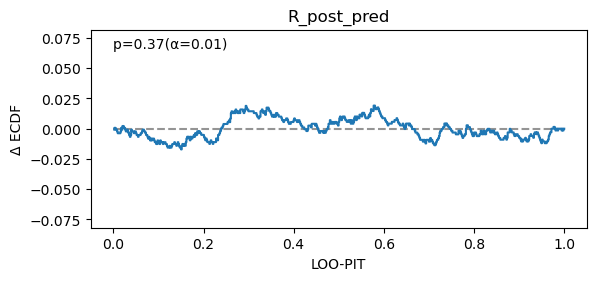

In [11]:
az.plot_loo_pit(cctr_idata)

### $R$, $S$, $g$, Cross-Classified, Reduced

In [ ]:
r_s_g_cc_reduced = cmdstanpy.CmdStanModel(stan_file='severity__reported_R__settlement_S__development_g__cross_classified_reduced.stan')

In [ ]:
N_unsettled = itd_data['settlement_lag'].apply(pd.isna).sum()
mcmc_inits = {
    'S_log_lambda_mu': 0,
    'S_log_lambda_sigma_rnlob': 0.10,
    'S_log_lambda_sigma_svrty': 0.10,
    'X_log_alpha_mu': -1,
    'X_log_beta_mu': -3,
    'X_log_alpha_sigma_class': 0.10,
    'X_log_beta_sigma_class': 0.10,
    'X_log_alpha_sigma_state': 0.10,
    # 'X_log_beta_sigma_state': 0.10,
    'X_log_alpha_sigma_rnlob': 0.10,
    'X_log_beta_sigma_rnlob': 0.10,
    # 'X_log_alpha_sigma_svrty': 0.10,
    'X_log_beta_sigma_svrty': 0.10,
    'X_log_alpha_sigma_cause': 0.10,
    'X_log_beta_sigma_cause': 0.10,
    'g_log_alpha_mu': 0.00,
    'g_log_alpha_sigma_rnlob': 0.10,
    # 'g_log_alpha_sigma_svrty': 0.10,
    # 'X_log_scale_trend_mu': 0.05,
    # 'X_log_scale_trend_sigma_rnlob': 0.01,

    'X_log_alpha_class_z': np.random.standard_normal(size=itd_stan_data['K_class']) / 10,
    'X_log_alpha_state_z': np.random.standard_normal(size=itd_stan_data['K_state']) / 10,
    'X_log_alpha_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    # 'X_log_alpha_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'X_log_alpha_cause_z': np.random.standard_normal(size=itd_stan_data['K_cause']) / 10,
    'X_log_beta_class_z': np.random.standard_normal(size=itd_stan_data['K_class']) / 10,
    # 'X_log_beta_state_z': np.random.standard_normal(size=itd_stan_data['K_state']) / 10,
    'X_log_beta_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'X_log_beta_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'X_log_beta_cause_z': np.random.standard_normal(size=itd_stan_data['K_cause']) / 10,
    'S_log_lambda_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'S_log_lambda_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'g_log_alpha_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    # 'g_log_alpha_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    # 'X_log_scale_trend_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 100,

    'S_unknown_minus_age': 1 +  np.random.standard_normal(size=N_unsettled) / 10
}
posterior_r_s_g_cc_reduced = r_s_g_cc_reduced.sample(
    data=itd_stan_data,
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    inits=mcmc_inits,
    adapt_delta=0.99
)

In [ ]:
ccr_idata = az.from_cmdstanpy(
    posterior=posterior_r_s_g_cc_reduced,
    posterior_predictive='R_post_pred',
    observed_data={'R_post_pred': itd_data['incurred_loss']},
    log_likelihood={'R_post_pred': 'R_log_lik'},
    dims={
        'X_log_alpha_class_z': ['class'],
        'X_log_alpha_state_z': ['state'],
        'X_log_alpha_rnlob_z': ['rnlob'],
        'X_log_beta_class_z': ['class'],
        'X_log_beta_rnlob_z': ['rnlob'],
        'X_log_beta_svrty_z': ['svrty'],
        'S_log_lambda_rnlob_z': ['rnlob'],
        'S_log_lambda_svrty_z': ['svrty'],
        'g_log_alpha_rnlob_z': ['rnlob'],
        'X_log_scale_trend_rnlob_z': ['rnlob'],
        'R': ['obs_id'],
        'g_class': ['obs_id'],
        'g_state': ['obs_id'],
        'g_rnlob': ['obs_id'],
        'g_svrty': ['obs_id'],
        'R_post_pred': ['obs_id'],
        'R_log_lik': ['obs_id']
    },
    coords={
        'class': class_cat.cat.categories.tolist(),
        'state': state_cat.cat.categories.tolist(),
        'rnlob': list(product_groups.keys()),
        'svrty': ['1. High', '2. Mid', '3. Low'],
        'cause': cause_cat.cat.categories.tolist(),
        'obs_id': itd_data.index.tolist()
    }
)

In [ ]:
az.plot_loo_pit(ccr_idata)

### Comparison

In [ ]:
az.compare({
    'cross-classified': cc_idata,
    'cross-classified & trended': cct_idata,
    'cross-classified & trended, reduced': cctr_idata,
    'cross-classified, reduced': ccr_idata,
    'baseline': noncc_idata
})

In [ ]:
selected_loss_model = r_s_g_cc_t_reduced

## Loss & DCC Models

### WINNER: Same model, but this time with hurdling

In [12]:
r_s_g_cctrh = cmdstanpy.CmdStanModel(stan_file='severity__reported_R__settlement_S__development_g__cross_classified_trended_reduced_hurdled.stan')

In [13]:
mcmc_inits = {
    'S_log_lambda_mu': 0,
    'S_log_lambda_sigma_rnlob': 0.10,
    'S_log_lambda_sigma_svrty': 0.10,
    'X_log_alpha_mu': -1,
    'X_log_beta_mu': -3,
    'X_log_alpha_sigma_class': 0.10,
    'X_log_beta_sigma_class': 0.10,
    'X_log_alpha_sigma_state': 0.10,
    # 'X_log_beta_sigma_state': 0.10,
    'X_log_alpha_sigma_rnlob': 0.10,
    'X_log_beta_sigma_rnlob': 0.10,
    # 'X_log_alpha_sigma_svrty': 0.10,
    'X_log_beta_sigma_svrty': 0.10,
    'X_log_alpha_sigma_cause': 0.10,
    'X_log_beta_sigma_cause': 0.10,
    'g_log_alpha_mu': 0.00,
    'g_log_alpha_sigma_rnlob': 0.10,
    # 'g_log_alpha_sigma_svrty': 0.10,
    'X_log_scale_trend_mu': 0.05,
    'X_log_scale_trend_sigma_rnlob': 0.01,

    'X_log_alpha_class_z': np.random.standard_normal(size=itd_stan_data['K_class']) / 10,
    'X_log_alpha_state_z': np.random.standard_normal(size=itd_stan_data['K_state']) / 10,
    'X_log_alpha_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    # 'X_log_alpha_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'X_log_alpha_cause_z': np.random.standard_normal(size=itd_stan_data['K_cause']) / 10,
    'X_log_beta_class_z': np.random.standard_normal(size=itd_stan_data['K_class']) / 10,
    # 'X_log_beta_state_z': np.random.standard_normal(size=itd_stan_data['K_state']) / 10,
    'X_log_beta_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'X_log_beta_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'X_log_beta_cause_z': np.random.standard_normal(size=itd_stan_data['K_cause']) / 10,
    'S_log_lambda_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'S_log_lambda_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'g_log_alpha_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    # 'g_log_alpha_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'X_log_scale_trend_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 100,

    'S_unknown_minus_age': 1 +  np.random.standard_normal(size=N_unsettled) / 10
}
posterior_dcc_cctrh = r_s_g_cctrh.sample(
    data={**itd_stan_data, 'R': itd_data['incurred_dcc']},
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    inits=mcmc_inits,
    adapt_delta=0.99,
    output_dir="C:/Users/RyanKarel/stan_outputs"
)

13:23:51 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

13:31:10 - cmdstanpy - INFO - CmdStan done processing.
13:31:11 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: Exception: gamma_lpdf: Inverse scale parameter is 0, but must be positive finite! (in 'severity__reported_R__settlement_S__development_g__cross_classified_trended_reduced_hurdled.stan', line 32, column 16 to column 89) (in 'severity__reported_R__settlement_S__development_g__cross_classified_trended_reduced_hurdled.stan', line 359, column 4 to column 59)
	Exception: Exception: gamma_lpdf: Inverse scale parameter is 0, but must be positive finite! (in 'severity__reported_R__settlement_S__development_g__cross_classified_trended_reduced_hurdled.stan', line 32, column 16 to column 89) (in 'severity__reported_R__settlement_S__development_g__cross_classified_trended_reduced_hurdled.stan', line 359, column 4 to column 59)
	Exception: Exception: weibull_lcdf: Shape parameter is inf, but must be positive finite! (in 'severity__reported_R__settlement_S__development_g

In [14]:
dcc_cctrh_idata = az.from_cmdstanpy(
    posterior=posterior_dcc_cctrh,
    posterior_predictive='R_post_pred',
    observed_data={'R_post_pred': itd_data['incurred_dcc']},
    log_likelihood={'R_post_pred': 'R_log_lik'},
    dims={
        'X_log_alpha_class_z': ['class'],
        'X_log_alpha_state_z': ['state'],
        'X_log_alpha_rnlob_z': ['rnlob'],
        'X_log_beta_class_z': ['class'],
        'X_log_beta_rnlob_z': ['rnlob'],
        'X_log_beta_svrty_z': ['svrty'],
        'S_log_lambda_rnlob_z': ['rnlob'],
        'S_log_lambda_svrty_z': ['svrty'],
        'g_log_alpha_rnlob_z': ['rnlob'],
        'X_log_scale_trend_rnlob_z': ['rnlob'],
        'R': ['obs_id'],
        'g_class': ['obs_id'],
        'g_state': ['obs_id'],
        'g_rnlob': ['obs_id'],
        'g_svrty': ['obs_id'],
        'R_post_pred': ['obs_id'],
        'R_log_lik': ['obs_id']
    },
    coords={
        'class': class_cat.cat.categories.tolist(),
        'state': state_cat.cat.categories.tolist(),
        'rnlob': list(product_groups.keys()),
        'svrty': ['1. High', '2. Mid', '3. Low'],
        'cause': cause_cat.cat.categories.tolist(),
        'obs_id': itd_data.index.tolist()
    }
)

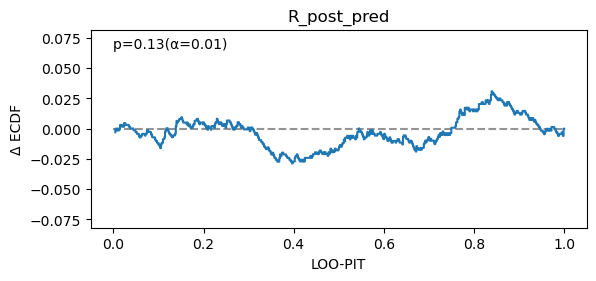

In [15]:
az.plot_loo_pit(dcc_cctrh_idata)

##### Evaluate loss and DCC together

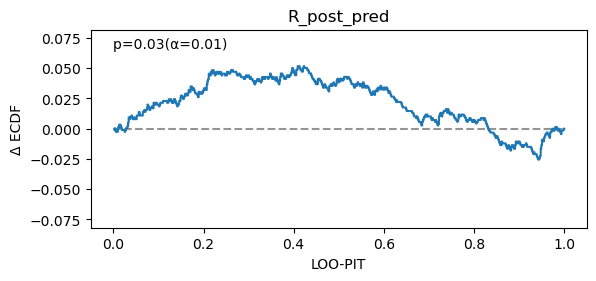

In [ ]:
loss_posterior = posterior_r_s_g_cc_t_reduced
loss_idata = cctr_idata
dcc_posterior = posterior_dcc_cctrh
dcc_idata = dcc_cctrh_idata

# I relied on Gemini to get this method of combining the two idatas
import xarray as xr

obs_total = loss_idata.observed_data["R_post_pred"] + dcc_idata.observed_data["R_post_pred"]
pred_total = loss_idata.posterior_predictive["R_post_pred"] + dcc_idata.posterior_predictive["R_post_pred"]
log_lik_total = loss_idata.log_likelihood["R_post_pred"] + dcc_idata.log_likelihood["R_post_pred"]

# RK note: this dummy approach seems to work, at least insofar as the plot does not change when I use either the loss
# or DCC idata.
dummy_posterior = dcc_idata["posterior"]

data_dict = {
    "observed_data": obs_total.to_dataset(name="R_post_pred"),
    "posterior_predictive": pred_total.to_dataset(name="R_post_pred"),
    "log_likelihood": log_lik_total.to_dataset(name="R_post_pred"),
    "posterior": dummy_posterior
}

combined_idata = xr.DataTree.from_dict(data_dict)

az.plot_loo_pit(
    combined_idata,
    var_names='R_post_pred'
)


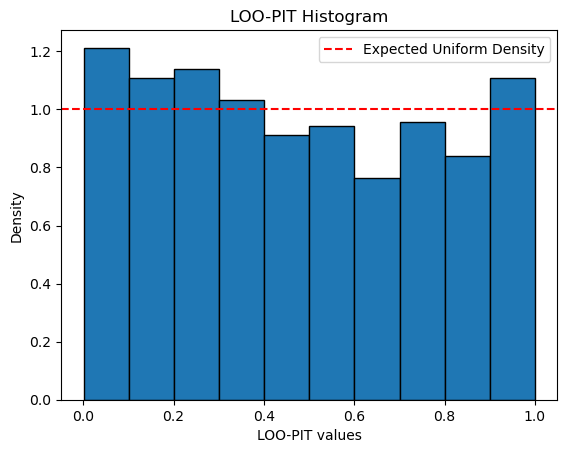

In [23]:
# histogram of LOO PIT values
loo_pit_vals = az.loo_pit(combined_idata, var_names="R_post_pred")['R_post_pred'].values

plt.hist(loo_pit_vals, bins=10, density=True, edgecolor="black")
plt.axhline(1.0, color="red", linestyle="--", label="Expected Uniform Density")
plt.xlabel("LOO-PIT values")
plt.ylabel("Density")
plt.title("LOO-PIT Histogram")
plt.legend()
plt.show()

Although each model does handle the two variables' distributions fairly well separately, there's definitely a relationship between the two that's currently not being modeled.

### Obsolete - these don't allow for strict zeros

#### Same model as loss, separate targets/training

Just reuse a decent model from above but on DCC, then test validity on DCC alone, then Loss + DCC together.

In [ ]:
mcmc_inits = {
    'S_log_lambda_mu': 0,
    'S_log_lambda_sigma_rnlob': 0.10,
    'S_log_lambda_sigma_svrty': 0.10,
    'X_log_alpha_mu': -1,
    'X_log_beta_mu': -3,
    'X_log_alpha_sigma_class': 0.10,
    'X_log_beta_sigma_class': 0.10,
    'X_log_alpha_sigma_state': 0.10,
    # 'X_log_beta_sigma_state': 0.10,
    'X_log_alpha_sigma_rnlob': 0.10,
    'X_log_beta_sigma_rnlob': 0.10,
    # 'X_log_alpha_sigma_svrty': 0.10,
    'X_log_beta_sigma_svrty': 0.10,
    'X_log_alpha_sigma_cause': 0.10,
    'X_log_beta_sigma_cause': 0.10,
    'g_log_alpha_mu': 0.00,
    'g_log_alpha_sigma_rnlob': 0.10,
    # 'g_log_alpha_sigma_svrty': 0.10,
    'X_log_scale_trend_mu': 0.05,
    'X_log_scale_trend_sigma_rnlob': 0.01,

    'X_log_alpha_class_z': np.random.standard_normal(size=itd_stan_data['K_class']) / 10,
    'X_log_alpha_state_z': np.random.standard_normal(size=itd_stan_data['K_state']) / 10,
    'X_log_alpha_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    # 'X_log_alpha_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'X_log_alpha_cause_z': np.random.standard_normal(size=itd_stan_data['K_cause']) / 10,
    'X_log_beta_class_z': np.random.standard_normal(size=itd_stan_data['K_class']) / 10,
    # 'X_log_beta_state_z': np.random.standard_normal(size=itd_stan_data['K_state']) / 10,
    'X_log_beta_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'X_log_beta_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'X_log_beta_cause_z': np.random.standard_normal(size=itd_stan_data['K_cause']) / 10,
    'S_log_lambda_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'S_log_lambda_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'g_log_alpha_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    # 'g_log_alpha_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'X_log_scale_trend_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 100,

    'S_unknown_minus_age': 1 +  np.random.standard_normal(size=N_unsettled) / 10
}
posterior_dcc = r_s_g_cc_reduced.sample(
    data={**itd_stan_data, 'R': itd_data['incurred_dcc']},
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    inits=mcmc_inits,
    adapt_delta=0.99
)

In [ ]:
dcc_idata = az.from_cmdstanpy(
    posterior=posterior_dcc,
    posterior_predictive='R_post_pred',
    observed_data={'R_post_pred': itd_data['incurred_dcc']},
    log_likelihood={'R_post_pred': 'R_log_lik'},
    dims={
        'X_log_alpha_class_z': ['class'],
        'X_log_alpha_state_z': ['state'],
        'X_log_alpha_rnlob_z': ['rnlob'],
        'X_log_beta_class_z': ['class'],
        'X_log_beta_rnlob_z': ['rnlob'],
        'X_log_beta_svrty_z': ['svrty'],
        'S_log_lambda_rnlob_z': ['rnlob'],
        'S_log_lambda_svrty_z': ['svrty'],
        'g_log_alpha_rnlob_z': ['rnlob'],
        'X_log_scale_trend_rnlob_z': ['rnlob'],
        'R': ['obs_id'],
        'g_class': ['obs_id'],
        'g_state': ['obs_id'],
        'g_rnlob': ['obs_id'],
        'g_svrty': ['obs_id'],
        'R_post_pred': ['obs_id'],
        'R_log_lik': ['obs_id']
    },
    coords={
        'class': class_cat.cat.categories.tolist(),
        'state': state_cat.cat.categories.tolist(),
        'rnlob': list(product_groups.keys()),
        'svrty': ['1. High', '2. Mid', '3. Low'],
        'cause': cause_cat.cat.categories.tolist(),
        'obs_id': itd_data.index.tolist()
    }
)

In [ ]:
# histogram of LOO PIT values
loo_pit_vals = az.loo_pit(dcc_idata, var_names="R_post_pred")['R_post_pred'].values

plt.hist(loo_pit_vals, bins=10, density=True, edgecolor="black")
plt.axhline(1.0, color="red", linestyle="--", label="Expected Uniform Density")
plt.xlabel("LOO-PIT values")
plt.ylabel("Density")
plt.title("LOO-PIT Histogram")
plt.legend()
plt.show()

In [ ]:
az.plot_loo_pit(dcc_idata)

#### DCC Ratio

In [ ]:
loss_dcc_cct_dcc_ratio = cmdstanpy.CmdStanModel(stan_file='severity__R_loss__D_dcc__cross_classified__trended__dcc_ratio.stan')

In [ ]:
mcmc_inits = {
    'S_log_lambda_mu': 0,
    'S_log_lambda_sigma_rnlob': 0.10,
    'S_log_lambda_sigma_svrty': 0.10,
    'X_log_alpha_mu': -1,
    'X_log_beta_mu': -3,
    'X_log_alpha_sigma_class': 0.10,
    'X_log_beta_sigma_class': 0.10,
    'X_log_alpha_sigma_state': 0.10,
    'X_log_beta_sigma_state': 0.10,
    'X_log_alpha_sigma_rnlob': 0.10,
    'X_log_beta_sigma_rnlob': 0.10,
    'X_log_alpha_sigma_svrty': 0.10,
    'X_log_beta_sigma_svrty': 0.10,
    'X_log_alpha_sigma_cause': 0.10,
    'X_log_beta_sigma_cause': 0.10,
    'g_log_alpha_mu': 0.00,
    'g_log_alpha_sigma_rnlob': 0.10,
    'g_log_alpha_sigma_svrty': 0.10,
    'X_log_scale_trend_mu': 0.05,
    'X_log_scale_trend_sigma_rnlob': 0.01,
    'X_log_scale_dcc_ratio_mu': -1.8,
    'X_log_scale_dcc_ratio_sigma_rnlob': 0.1,
    'X_log_scale_dcc_ratio_sigma_svrty': 0.1,

    'X_log_alpha_class_z': np.random.standard_normal(size=itd_stan_data['K_class']) / 10,
    'X_log_alpha_state_z': np.random.standard_normal(size=itd_stan_data['K_state']) / 10,
    'X_log_alpha_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'X_log_alpha_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'X_log_alpha_cause_z': np.random.standard_normal(size=itd_stan_data['K_cause']) / 10,
    'X_log_beta_class_z': np.random.standard_normal(size=itd_stan_data['K_class']) / 10,
    'X_log_beta_state_z': np.random.standard_normal(size=itd_stan_data['K_state']) / 10,
    'X_log_beta_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'X_log_beta_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'X_log_beta_cause_z': np.random.standard_normal(size=itd_stan_data['K_cause']) / 10,
    'S_log_lambda_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'S_log_lambda_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'g_log_alpha_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'g_log_alpha_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'X_log_scale_trend_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 100,
    'X_log_scale_dcc_ratio_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'X_log_scale_dcc_ratio_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,

    'S_unknown_minus_age': 1 +  np.random.standard_normal(size=N_unsettled) / 10
}
posterior_loss_dcc_cct_dcc_ratio = loss_dcc_cct_dcc_ratio.sample(
    data=itd_stan_data,
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    inits=mcmc_inits,
    adapt_delta=0.97
)

In [ ]:
idata_loss_dcc_cct_dcc_ratio = az.from_cmdstanpy(
    posterior=posterior_loss_dcc_cct_dcc_ratio,
    posterior_predictive=['R_post_pred', 'D_post_pred'],
    observed_data={
        'R_post_pred': itd_data['incurred_loss'],
        'D_post_pred': itd_data['incurred_dcc']
    },
    log_likelihood={
        'R_post_pred': 'R_log_lik',
        'D_post_pred': 'D_log_lik'
    },
    dims={
        'X_log_alpha_class_z': ['class'],
        'X_log_alpha_state_z': ['state'],
        'X_log_alpha_rnlob_z': ['rnlob'],
        'X_log_alpha_svrty_z': ['svrty'],
        'X_log_beta_class_z': ['class'],
        'X_log_beta_state_z': ['state'],
        'X_log_beta_rnlob_z': ['rnlob'],
        'X_log_beta_svrty_z': ['svrty'],
        'S_log_lambda_rnlob_z': ['rnlob'],
        'S_log_lambda_svrty_z': ['svrty'],
        'g_log_alpha_rnlob_z': ['rnlob'],
        'g_log_alpha_svrty_z': ['svrty'],
        'X_log_scale_trend_rnlob_z': ['rnlob'],
        'R': ['obs_id'],
        'g_class': ['obs_id'],
        'g_state': ['obs_id'],
        'g_rnlob': ['obs_id'],
        'g_svrty': ['obs_id'],
        'R_post_pred': ['obs_id'],
        'R_log_lik': ['obs_id'],
        'D_log_lik': ['obs_id']
    },
    coords={
        'class': class_cat.cat.categories.tolist(),
        'state': state_cat.cat.categories.tolist(),
        'rnlob': list(product_groups.keys()),
        'svrty': ['1. High', '2. Mid', '3. Low'],
        'cause': cause_cat.cat.categories.tolist(),
        'obs_id': itd_data.index.tolist()
    }
)

In [ ]:
az.plot_trace_dist(
    idata_loss_dcc_cct_dcc_ratio,
    var_names=[
        'X_log_scale_trend_mu',
        'X_log_scale_trend_sigma_rnlob',
        'X_log_scale_dcc_ratio_mu',
        'X_log_scale_dcc_ratio_sigma_rnlob',
        'X_log_scale_dcc_ratio_sigma_svrty'
    ]
)
plt.tight_layout()

In [ ]:
# histogram of LOO PIT values - Loss
loo_pit_vals = az.loo_pit(idata_loss_dcc_cct_dcc_ratio, var_names="R_post_pred")['R_post_pred'].values

plt.hist(loo_pit_vals, bins=10, density=True, edgecolor="black")
plt.axhline(1.0, color="red", linestyle="--", label="Expected Uniform Density")
plt.xlabel("LOO-PIT values")
plt.ylabel("Density")
plt.title("LOO-PIT Histogram for Reported Loss (R)")
plt.legend()
plt.show()

# histogram of LOO PIT values - DCC
loo_pit_vals = az.loo_pit(idata_loss_dcc_cct_dcc_ratio, var_names="D_post_pred")['D_post_pred'].values

plt.hist(loo_pit_vals, bins=10, density=True, edgecolor="black")
plt.axhline(1.0, color="red", linestyle="--", label="Expected Uniform Density")
plt.xlabel("LOO-PIT values")
plt.ylabel("Density")
plt.title("LOO-PIT Histogram for Reported DCC (D)")
plt.legend()
plt.show()

In [ ]:
az.plot_loo_pit(idata_loss_dcc_cct_dcc_ratio)

#### DCC Ratio, Varying $g$

In [ ]:
loss_dcc_cct_varying_g = cmdstanpy.CmdStanModel(stan_file='severity__R_loss__D_dcc__cross_classified__trended__varying_g.stan')

In [ ]:
mcmc_inits = {
    'S_log_lambda_mu': 0,
    'S_log_lambda_sigma_rnlob': 0.10,
    'S_log_lambda_sigma_svrty': 0.10,
    'X_log_alpha_mu': -1,
    'X_log_beta_mu': -3,
    'X_log_alpha_sigma_class': 0.10,
    'X_log_beta_sigma_class': 0.10,
    'X_log_alpha_sigma_state': 0.10,
    'X_log_beta_sigma_state': 0.10,
    'X_log_alpha_sigma_rnlob': 0.10,
    'X_log_beta_sigma_rnlob': 0.10,
    'X_log_alpha_sigma_svrty': 0.10,
    'X_log_beta_sigma_svrty': 0.10,
    'X_log_alpha_sigma_cause': 0.10,
    'X_log_beta_sigma_cause': 0.10,
    'g_log_alpha_mu': 0.00,
    'g_log_alpha_sigma_rnlob': 0.10,
    'g_log_alpha_sigma_svrty': 0.10,
    'g_log_alpha_D_delta': -0.5,
    'X_log_scale_trend_mu': 0.05,
    'X_log_scale_trend_sigma_rnlob': 0.01,
    'X_log_scale_dcc_ratio_mu': -1.8,
    'X_log_scale_dcc_ratio_sigma_rnlob': 0.1,
    'X_log_scale_dcc_ratio_sigma_svrty': 0.1,

    'X_log_alpha_class_z': np.random.standard_normal(size=itd_stan_data['K_class']) / 10,
    'X_log_alpha_state_z': np.random.standard_normal(size=itd_stan_data['K_state']) / 10,
    'X_log_alpha_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'X_log_alpha_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'X_log_alpha_cause_z': np.random.standard_normal(size=itd_stan_data['K_cause']) / 10,
    'X_log_beta_class_z': np.random.standard_normal(size=itd_stan_data['K_class']) / 10,
    'X_log_beta_state_z': np.random.standard_normal(size=itd_stan_data['K_state']) / 10,
    'X_log_beta_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'X_log_beta_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'X_log_beta_cause_z': np.random.standard_normal(size=itd_stan_data['K_cause']) / 10,
    'S_log_lambda_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'S_log_lambda_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'g_log_alpha_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'g_log_alpha_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'X_log_scale_trend_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 100,
    'X_log_scale_dcc_ratio_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'X_log_scale_dcc_ratio_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,

    'S_unknown_minus_age': 1 +  np.random.standard_normal(size=N_unsettled) / 10
}
posterior_loss_dcc_cct_varying_g = loss_dcc_cct_varying_g.sample(
    data=itd_stan_data,
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    inits=mcmc_inits,
    adapt_delta=0.97
)

In [ ]:
idata_loss_dcc_cct_varying_g = az.from_cmdstanpy(
    posterior=posterior_loss_dcc_cct_varying_g,
    posterior_predictive=['R_post_pred', 'D_post_pred'],
    observed_data={
        'R_post_pred': itd_data['incurred_loss'],
        'D_post_pred': itd_data['incurred_dcc']
    },
    log_likelihood={
        'R_post_pred': 'R_log_lik',
        'D_post_pred': 'D_log_lik'
    },
    dims={
        'X_log_alpha_class_z': ['class'],
        'X_log_alpha_state_z': ['state'],
        'X_log_alpha_rnlob_z': ['rnlob'],
        'X_log_alpha_svrty_z': ['svrty'],
        'X_log_beta_class_z': ['class'],
        'X_log_beta_state_z': ['state'],
        'X_log_beta_rnlob_z': ['rnlob'],
        'X_log_beta_svrty_z': ['svrty'],
        'S_log_lambda_rnlob_z': ['rnlob'],
        'S_log_lambda_svrty_z': ['svrty'],
        'g_log_alpha_rnlob_z': ['rnlob'],
        'g_log_alpha_svrty_z': ['svrty'],
        'X_log_scale_trend_rnlob_z': ['rnlob'],
        'R': ['obs_id'],
        'g_class': ['obs_id'],
        'g_state': ['obs_id'],
        'g_rnlob': ['obs_id'],
        'g_svrty': ['obs_id'],
        'R_post_pred': ['obs_id'],
        'R_log_lik': ['obs_id'],
        'D_log_lik': ['obs_id']
    },
    coords={
        'class': class_cat.cat.categories.tolist(),
        'state': state_cat.cat.categories.tolist(),
        'rnlob': list(product_groups.keys()),
        'svrty': ['1. High', '2. Mid', '3. Low'],
        'cause': cause_cat.cat.categories.tolist(),
        'obs_id': itd_data.index.tolist()
    }
)

In [ ]:
posterior_loss_dcc_cct_varying_g.draws_pd('X_beta_D')

In [ ]:
# histogram of LOO PIT values - Loss
loo_pit_vals = az.loo_pit(idata_loss_dcc_cct_varying_g, var_names="R_post_pred")['R_post_pred'].values

plt.hist(loo_pit_vals, bins=10, density=True, edgecolor="black")
plt.axhline(1.0, color="red", linestyle="--", label="Expected Uniform Density")
plt.xlabel("LOO-PIT values")
plt.ylabel("Density")
plt.title("LOO-PIT Histogram for Reported Loss (R)")
plt.legend()
plt.show()

# histogram of LOO PIT values - DCC
loo_pit_vals = az.loo_pit(idata_loss_dcc_cct_varying_g, var_names="D_post_pred")['D_post_pred'].values

plt.hist(loo_pit_vals, bins=10, density=True, edgecolor="black")
plt.axhline(1.0, color="red", linestyle="--", label="Expected Uniform Density")
plt.xlabel("LOO-PIT values")
plt.ylabel("Density")
plt.title("LOO-PIT Histogram for Reported DCC (D)")
plt.legend()
plt.show()

In [ ]:
az.plot_loo_pit(idata_loss_dcc_cct_varying_g)

# Obsolete Time Series Attempt

## Time Series Data Prep

In [ ]:
sql =     """
with claim_stats as (
    select
        num_claim,
        num_policy,
        c.cd_cause_of_loss,
        c.cd_severity,
        p.cd_product,
        c.cd_occurrence_state,
        lcg.cd_group_name as cd_largest_class_group,
        coalesce(p.amt_occurrence_limit, p.amt_claim_limit) as amt_claim_limit,
        c.dt_claim_report,
        timestamp_settlement as dt_settlement,
        if(cd_claim_status = 'Closed', dt_claim_closed) as dt_claim_closed,
        cast(
            greatest(
                ceiling(
                    date_diff(
                        'day',
                        dt_claim_report,
                        coalesce(timestamp_settlement, if(cd_claim_status = 'Closed', dt_claim_closed))
                    ) / (365.0 / 4)
                ),
                1
            )
            as int
        ) as settlement_lag,
        cast(
            greatest(
                ceiling(
                    date_diff(
                        'day',
                        dt_claim_report, -- making everything relative to report date for consistency
                        if(cd_claim_status = 'Closed', dt_claim_closed)
                    ) / (365.0 / 4)
                ),
                1
            )
            as int
        ) as closure_lag,
        cast(
            greatest(
                floor( -- we're using floor to remove the partial period
                    date_diff(
                        'day',
                        dt_claim_report,
                        current_timestamp
                    ) / (365.0 / 4)
                ),
                1
            )
            as int
        ) as age
    from tbl_claim c
    inner join tbl_policy p using (num_policy)
    left join (select num_claim, timestamp_settlement from tbl_settlement) s using (num_claim)
    left join vw_largest_class_group lcg using (num_policy)
    where
        coalesce(p.amt_total_attachment, 0) = 0 -- primary layer only
        and p.cd_product not in ('CP', 'IM') -- non property
        and dt_claim_report < current_timestamp - interval '6' month
),

transactions as (
    select
        num_claim,
        ceil(
            greatest(
                date_diff('day', dt_claim_report, timestamp_claim_transaction) / (365.0 / 4),
                1
            )
        ) as t,
        age,
        sum(coalesce(amt_paid, 0)) filter (where ind_loss and not ind_recovery) as paid_loss_t,
        sum(coalesce(amt_incurred, 0)) filter (where ind_loss and not ind_recovery) as incurred_loss_t,
        sum(coalesce(amt_paid, 0)) filter (where ind_dcc and not ind_recovery) as paid_dcc_t,
        sum(coalesce(amt_incurred, 0)) filter (where ind_dcc and not ind_recovery) as incurred_dcc_t,
        sum(coalesce(amt_incurred, 0)) filter (where ind_recovery) as recoveries_t
    from (
        select
            *,
            cd_financial_type = 'Loss' as ind_loss,
            cd_financial_type = 'DCC' as ind_dcc,
            cd_claim_transaction_type like 'Recov%' as ind_recovery
        from tbl_claim_transaction
    ) t
    inner join claim_stats c using (num_claim)
    where cd_financial_type != 'AO'
    group by 1, 2, 3
    order by 2
),

time_series as (
    select
        num_claim,
        map_agg(cast(t as int), paid_loss_t) filter (where paid_loss_t != 0) as paid_loss_t,
        map_agg(cast(t as int), incurred_loss_t) filter (where incurred_loss_t != 0) as incurred_loss_t,
        map_agg(cast(t as int), paid_dcc_t) filter (where paid_dcc_t != 0) as paid_dcc_t,
        map_agg(cast(t as int), incurred_dcc_t) filter (where incurred_dcc_t != 0) as incurred_dcc_t,
        map_agg(cast(t as int), recoveries_t) filter (where recoveries_t != 0) as recoveries_t
    from transactions
    where
        -- remove all the transactions that have not happened by the latest full quarter of the claim's history
        t <= age
    group by num_claim
)

select
    num_claim,
    num_policy,
    paid_loss_t,
    incurred_loss_t,
    paid_dcc_t,
    incurred_dcc_t,
    recoveries_t,
    cd_cause_of_loss,
    cd_severity,
    cd_product,
    cd_occurrence_state,
    cd_largest_class_group,
    amt_claim_limit,
    dt_claim_report,
    dt_settlement,
    dt_claim_closed,
    if(settlement_lag <= age, settlement_lag) as settlement_lag,
    if(closure_lag <= age, closure_lag) as closure_lag,
    if(closure_lag <= age, closure_lag - settlement_lag) as settlement_to_closure_lag,
    age
from time_series ts
inner join claim_stats using (num_claim)
    """

In [ ]:
data = query_athena(
    sql,
    boto3_session=boto3_session
)
data = data.set_index('num_claim')

scale = 1000

# recover the compact time series
def recover_time_series(s):
    if pd.isna(s):
        return {}
    transactions = [entry.split('=') for entry in s[1:-1].split(', ')]
    return {
        int(t): round(float(x_t) / scale, 2)
        for t, x_t in transactions
    }
data['paid_loss_t'] = data['paid_loss_t'].apply(recover_time_series)
data['incurred_loss_t'] = data['incurred_loss_t'].apply(recover_time_series)
data['paid_dcc_t'] = data['paid_dcc_t'].apply(recover_time_series)
data['incurred_dcc_t'] = data['incurred_dcc_t'].apply(recover_time_series)
data['recoveries_t'] = data['recoveries_t'].apply(recover_time_series)

data

In [ ]:
# let's get a wide form of loss incurred series
max_known_t = data['age'].max()
loss_incurred = np.zeros((len(data), max_known_t))
for i, x_t in enumerate(data['incurred_loss_t']):
    t_settlement = data.iloc[i].loc['age']
    for t in range(1, max_known_t + 1):
        if t > t_settlement:
            value = np.nan
        elif t in x_t:
            value = x_t[t]
        else:
            value = 0.0
        loss_incurred[i, t-1] = value

loss_incurred = pd.DataFrame(loss_incurred, index=data.index, columns=range(1, max_known_t + 1))
loss_incurred

In [ ]:
# let's get a wide form of loss paid series
max_known_t = data['age'].max()
loss_paid = np.zeros((len(data), max_known_t))
for i, x_t in enumerate(data['paid_loss_t']):
    t_settlement = data.iloc[i].loc['age']
    for t in range(1, max_known_t + 1):
        if t > t_settlement:
            value = np.nan
        elif t in x_t:
            value = x_t[t]
        else:
            value = 0.0
        loss_paid[i, t-1] = value

loss_paid = pd.DataFrame(loss_paid, index=data.index, columns=range(1, max_known_t + 1))
loss_paid

## Attempted Time Series Models

In [ ]:
expected_long_incurred = loss_incurred.stack().dropna()
expected_long_paid = loss_paid.stack().dropna()
assert len(expected_long_incurred) == len(expected_long_paid)
expected_N_long = len(expected_long_incurred)

In [ ]:
stan_data = {
    'N': len(loss_paid),
    'K': len(loss_paid.columns),
    'Inc': loss_incurred,
    'Paid': loss_paid,
    's': data['settlement_lag'].fillna(-1).astype(int),
    'c': data['closure_lag'].fillna(-1).astype(int),
    'age': data['age'].astype(int),

    'expected_N_long': expected_N_long,
    'expected_long_paid': expected_long_paid,
    'expected_long_incurred': expected_long_incurred
}

### Null Model

In [ ]:
null_stan_model = cmdstanpy.CmdStanModel(stan_file='severity_null.stan')

In [ ]:
posterior_null = null_stan_model.sample(
    data=stan_data,
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling
)

In [ ]:
posterior_null.summary()

### Basic settlement lag and known severity model

In [ ]:
basic_settlement_known_severity = cmdstanpy.CmdStanModel(stan_file='severity_settlement_loss.stan')

In [ ]:
posterior_basic_known = basic_settlement_known_severity.sample(
    data=stan_data,
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling
)
posterior_basic_known.summary()

### $S$, $X$, $r_t$

In [ ]:
s_x_rt = cmdstanpy.CmdStanModel(stan_file='severity__settlement_S__severity_X__reported_submartingale_r_t__log_parameterization.stan')

In [ ]:
N_not_settled = len(data['settlement_lag']) - len(data['settlement_lag'].dropna())
mcmc_inits = {
    'log_S_exponential_rate' : np.log(0.25),
    'X_hurdle_p0': 0.20,
    'X_lognorm_mu': 6,
    'log_X_lognorm_sigma': 0,
    'r_hurdle_p0': 0.6,
    'log_r_beta_decay_rate': -0.5,
    'log_r_gumbel_beta0': 4,
    'S_unknown_minus_age': 4 + np.random.standard_normal(size=N_not_settled) / 20,
    'z_X_unknown': np.random.standard_normal(size=N_not_settled) / 20
}
posterior_s_x_rt = s_x_rt.sample(
    data=stan_data,
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    # adapt_delta=0.95
)
# posterior_s_x_rt.summary()

In [ ]:
x='log_r_gumbel_beta0'
var_names=['log_S_exponential_rate', 'X_hurdle_p0', 'X_lognorm_mu', 'log_X_lognorm_sigma', 'r_hurdle_p0', 'log_r_gumbel_beta', 'treedepth__']
df = posterior_s_x_rt.draws_pd(vars=[x, 'treedepth__'])
df.plot(kind='scatter', x=x, y='treedepth__')

In [ ]:
print(posterior_s_x_rt.diagnose())

In [ ]:
# lets get an inferencedata object going so we can see where the issues are
idata = az.from_cmdstanpy(
    posterior=posterior_s_x_rt,
    posterior_predictive='r_post_pred',
    observed_data={'r_post_pred': expected_long_incurred},
    log_likelihood={'C_R_post_pred': 'r_log_lik'}
)

In [ ]:
# Diagnostic plots to identify sources of divergent transitions

# 1. Energy plot - checks for issues with HMC exploration
az.plot_energy(idata)
plt.show()

# 2. Parallel coordinates plot - shows divergences across parameters
az.plot_parallel(
    idata,
    var_names=['log_S_exponential_rate', 'X_hurdle_p0', 'X_lognorm_mu',
               'log_X_lognorm_sigma', 'r_hurdle_p0', 'log_r_gumbel_beta']
)
plt.show()

# 3. Pair plots with divergences highlighted for key parameters
az.plot_pair(
    idata,
    var_names=['log_S_exponential_rate', 'X_hurdle_p0', 'X_lognorm_mu',
               'log_X_lognorm_sigma', 'r_hurdle_p0', 'log_r_gumbel_beta'],
    visuals={'divergence': True}
)
plt.show()

# 4. Check divergence rate by chain
divergences_by_chain = idata.sample_stats['diverging'].sum(dim='draw')
print("Divergences by chain:")
print(divergences_by_chain.values)
print(f"Total divergences: {idata.sample_stats['diverging'].sum().item()}")
print(f"Total draws: {idata.sample_stats['diverging'].size}")

# 5. Look at S and X (per-claim latent parameters) - pick a subset to inspect
# since these are high-dimensional, check if divergences correlate with specific claims
diverging = idata.sample_stats['diverging'].values.flatten()
S_samples = idata.posterior['S_unknown_minus_age'].values.reshape(-1, idata.posterior['S_unknown_minus_age'].shape[-1])
X_samples = idata.posterior['z_X_unknown'].values.reshape(-1, idata.posterior['z_X_unknown'].shape[-1])

# Compare distributions of S and X between divergent and non-divergent draws
S_mean_diverging = S_samples[diverging].mean(axis=0)
S_mean_ok = S_samples[~diverging].mean(axis=0)
X_mean_diverging = X_samples[diverging].mean(axis=0)
X_mean_ok = X_samples[~diverging].mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(S_mean_ok, S_mean_diverging - S_mean_ok, alpha=0.5, s=10)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Mean S (all draws)')
axes[0].set_ylabel('Diff: divergent - overall mean')
axes[0].set_title('S: Divergent vs Non-divergent draws per claim')

axes[1].scatter(X_mean_ok, X_mean_diverging - X_mean_ok, alpha=0.5, s=10)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Mean X (all draws)')
axes[1].set_ylabel('Diff: divergent - overall mean')
axes[1].set_title('X: Divergent vs Non-divergent draws per claim')
plt.tight_layout()
plt.show()

# 6. Trace plot with divergences marked, for scalar parameters
az.plot_trace_dist(
    idata,
    var_names=['log_S_exponential_rate', 'X_hurdle_p0', 'X_lognorm_mu',
               'log_X_lognorm_sigma', 'r_hurdle_p0', 'log_r_gumbel_beta'],
    visuals={'divergence': True}
)
plt.tight_layout()
plt.show()